<a href="https://colab.research.google.com/github/swarnkarnitin/TrafficMonitoring/blob/main/Vision_Transformers_for_Object_detection_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tuning Vision Transformers for Object Detection

Welcome to the HuggingFace 🤗 Community Course Unit 3, Chapter 3; Transfer-Learning and Fine-tuning Vision Transformers. In this part, we will understand more on how we can fine-tune an existing Vision Transformer model for Object Detection. Before getting started, check out this HuggingFace Space, where you can play around with the final output.

```
<iframe
	src="https://huggingface.co/spaces/hf-vision/finetuning_demo_for_object_detection"
	frameborder="0"
	width="850"
	height="450">
</iframe>
```

Also there is a small section if you are interested in Transfer learning instead of fine tuning only.

## Introduction

![intro](https://huggingface.co/datasets/hf-vision/course-assets/resolve/main/object_detection_wiki.png)

Object detection is a computer vision task aims at identifying and localizing objects within an image or video. It involves two primary steps:

1. first, recognizing the types of objects present (such as cars, people, or animals).
2. Second, determining their precise locations by drawing bounding boxes around them.

The input to these models are often an image (static or a video frame) containing multiple objects. Example: An image containing objects like a car, a person, a cycle etc. The output of these models are simply some set of numbers, which tells us the following:

1. Where the object is located? (regressive output containing co-ordinates of the bounding box)
2. What is that object? (classification)

There are huge number of applications around object detection. One most significant example being in the fields of autonomous driving. Where Object detection is used to detect different objects (like pedestrians, road signs, and traffic lights etc)  around the car that becomes one of the input for taking decisions.

If you want to understand more around the ins-and-outs of object detection, check out our [dedicated chapter](#) on Object Detection 🤗

### Why do we need fine-tuning for object detection 🤔

That is an awesome question. Before reading the answer, checkout our definitions of fine-tuning and it's difference with transfer learning [here](#).

Training an object detection model from scratch means:

1. Doing already done research over and over again.
2. Writing repetitive model code and training them and maintaining different repositories for different use cases.
3. Lot of experimentation and waste of resources.

So, instead what we can do is, simply take a superstar pre-trained model (a model which does an awesome job in recognizing general features), and tweak or re-tune their weights (or some part of their weights) to adapt it for our use case. We believe or assume that, the pre-trained model has already learned enough to extract significant features inside an image to locate and classify objects. So, if new objects are introduced, then the same model can be trained for a small period of time and compute to start detecting those new objects with the help of already learned and new features.

### What to expect from this tutorial?

By the end of this tutorial, you should be able to make a full pipeline (from loading datasets, fine-tuning a model and doing inference) for object detection use case.

## Installation

Let's start with installation. Just execute the below cells to install the necessary packages. For this tutorial, we will be using Hugging Face 🤗 Transformers and PyTorch.

In [ ]:
!pip install -U -q datasets transformers[torch] evaluate timm albumentations accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 521.2/521.2 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 22.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 35.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 18.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 19.4 MB/s eta 0:00:00


## Scenario

To make this tutorial interesting, let's consider a real-world example. Consider this scenario: construction workers require the utmost safety when working in construction areas. Basic safety protocol requires wearing them helmet every time. Since there are lot of construction workers, it is hard to keep and eye on everyone everytime.

But, if we can have a camera system, which can detect persons and whether the person is wearing a helmet or not in real time, that would be awesome, right?

So, we are going to fine-tune a light weight object detection model for doing the same. Let's dive in.


### Dataset

Keeping in mind for the above scenerio, we will be using the [hardhat](https://huggingface.co/datasets/hf-vision/hardhat) dataset provided by [Northeaster University China](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/7CBGOS). We will be using 🤗 `datasets` to download and load this dataset.

In [ ]:
from datasets import load_dataset

dataset = load_dataset("anindya64/hardhat")
dataset

Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/5297 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1766 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'objects'],
        num_rows: 5297
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'objects'],
        num_rows: 1766
    })
})

In [ ]:
dataset['train'][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375>,
 'image_id': 1,
 'width': 500,
 'height': 375,
 'objects': {'id': [1, 1],
  'area': [3068.0, 690.0],
  'bbox': [[178.0, 84.0, 52.0, 59.0], [111.0, 144.0, 23.0, 30.0]],
  'category': ['helmet', 'helmet']}}

In [ ]:
# extract out the train and test set

train_dataset = dataset['train']
test_dataset = dataset['test']

So, we have around 5000 training samples and 1700 test samples. Let's first see, how one sample of the dataset looks like:

In [ ]:
sample = train_dataset[0]
sample

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375>,
 'image_id': 1,
 'width': 500,
 'height': 375,
 'objects': {'id': [1, 1],
  'area': [3068.0, 690.0],
  'bbox': [[178.0, 84.0, 52.0, 59.0], [111.0, 144.0, 23.0, 30.0]],
  'category': ['helmet', 'helmet']}}


1. `image`: This is a Pillow Image object that helps to look into the image directly before even loading from the path.
2. `image_id`: Denotes which number of image is from the train file.
3. `width`: The width of the image.
4. `height`: The height of the image.
5. `objects`:  Another dictionary containing information about annotation. This contains the following:
    1. `id`: A list, where length of list denotes the number of objects and value of each denotes the class index.
    2. `area`: The area of the object.
    3. `bbox`: Denotes bounding box coordinates of the object.
    4. `category`: The class (string) of the object.

Now, that we know what a sample data point contains, let's start with plotting that sample. Here we are going to first draw the image and then also draw the corresponding bounding box associated.

Here is what we are going to do:

1. Get the image and it's corresponding height and width.
2. Make a draw object that can easily draw text and lines on image.
3. Get the annotations dict from the sample.
4. Iterate over it.
5. For each, get the bounding box co-ordinates, which are x (where the bounding box starts horizontally), y (where the bounding box starts vertically), w (width of the bounding box), h (height of the bounding box).
6. Now if the bounding box measures are normalized then scale it, else leave it.
7. And finally draw the rectangle and the the class category text.

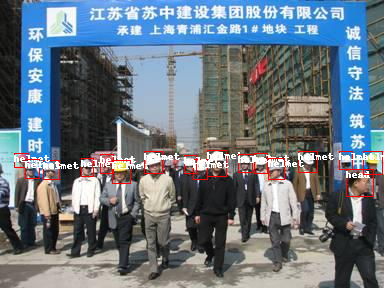

In [ ]:
import numpy as np
from PIL import Image, ImageDraw

def draw_image_from_idx(dataset, idx):
    sample = dataset[idx]
    image = sample["image"]
    annotations = sample['objects']
    draw = ImageDraw.Draw(image)
    width, height = sample['width'], sample['height']

    for i in range(len(annotations["id"])):
        box = annotations["bbox"][i]
        class_idx = annotations["id"][i]
        x, y, w, h = tuple(box)
        if max(box) > 1.0:
            x1, y1 = int(x), int(y)
            x2, y2 = int(x + w), int(y + h)
        else:
            x1 = int(x * width)
            y1 = int(y * height)
            x2 = int((x + w) * width)
            y2 = int((y + h) * height)
        draw.rectangle((x1, y1, x2, y2), outline="red", width=1)
        draw.text((x1, y1), annotations["category"][i], fill="white")
    return image


draw_image_from_idx(dataset=train_dataset, idx=10)

In [ ]:
# Now let's make a simple function on plotting multiple images

import matplotlib.pyplot as plt

def plot_images(dataset, indices):
    """
    Plot images and their annotations.
    """
    num_rows = len(indices) // 3
    num_cols = 3
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

    for i, idx in enumerate(indices):
        row = i // num_cols
        col = i % num_cols

        # Draw image
        image = draw_image_from_idx(dataset, idx)

        # Display image on the corresponding subplot
        axes[row, col].imshow(image)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

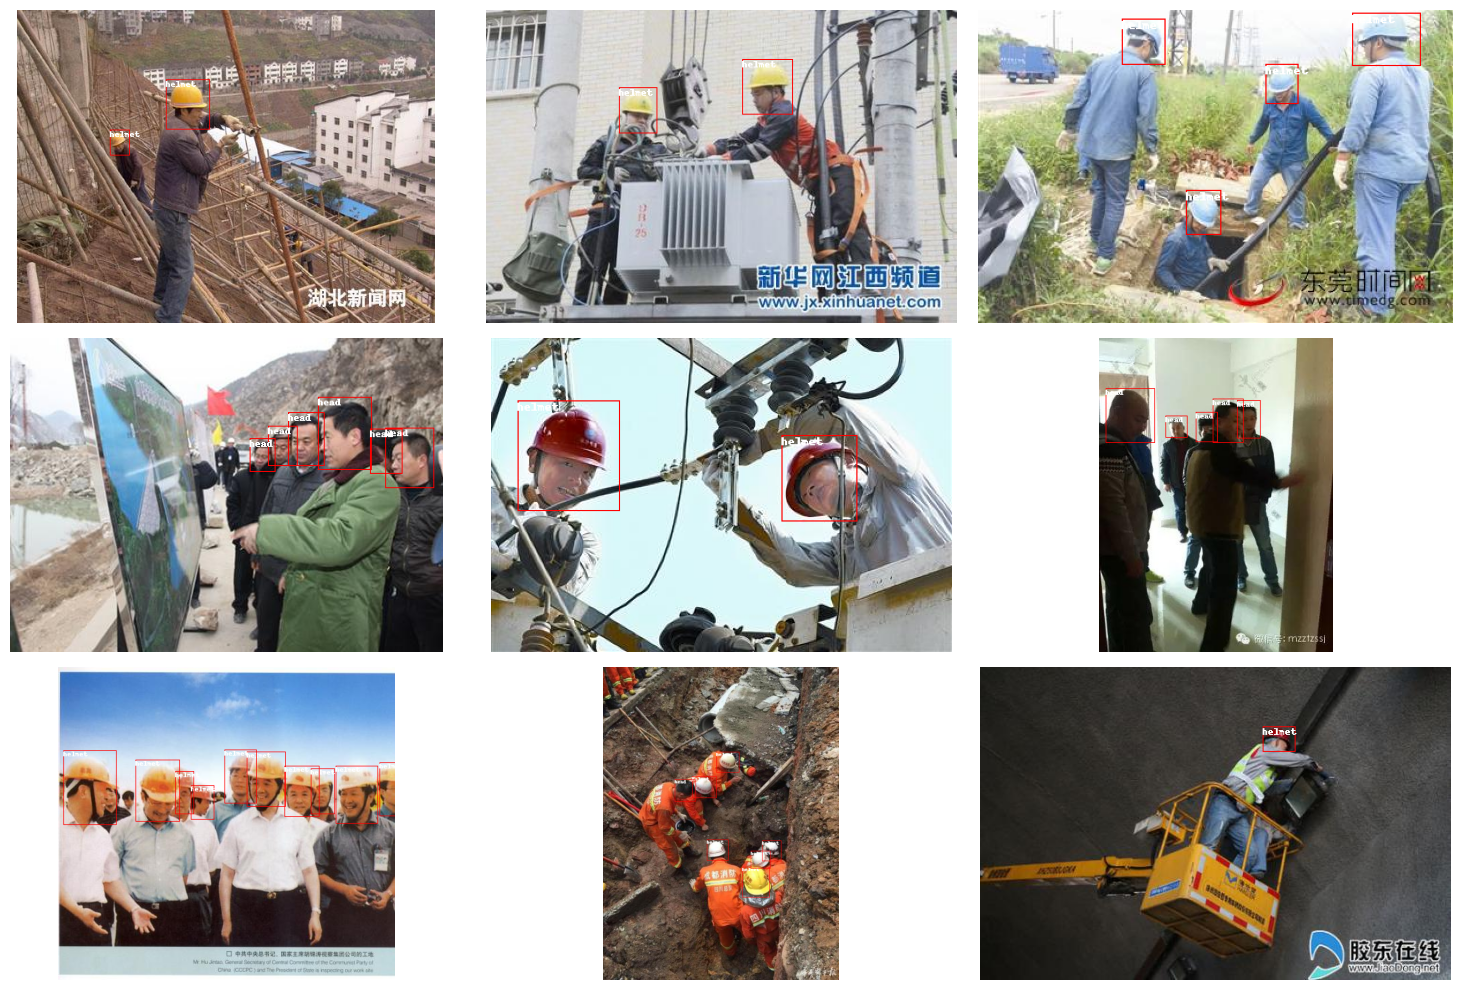

In [ ]:
plot_images(train_dataset, range(9))

## AutoImageProcessor

Before fine-tuning the model, we must preprocess the data in such a way that it matches exactly with the approach it was used during the time if pre-training. HuggingFace [AutoImageProcessor](https://huggingface.co/docs/transformers/v4.36.0/en/model_doc/auto#transformers.AutoImageProcessor) takes care of processing the image data to create pixel_values, pixel_mask, and labels that a DETR model can train with.

Now, let us instantiate the image processor from the same checkpoint we want to use our model to fine-tune.

In [ ]:
from transformers import AutoImageProcessor

checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.


## Preprocessing the dataset

In this section, we will preprocess the dataset. Basically, we will apply different types of augmentations to the images, along with their corresponding bounding boxes.

In simple terms, augmentations are some set of random transformations like rotations, resizing etc. These are applied for the following reasons:

1. To get more samples.
2. To make the vision model more robust towards different conditions of the image.

We will use the [albumentations](https://github.com/albumentations-team/albumentations) library to achieve this. If you want to dig deeper into different types of augmentations, check out the corresponding unit to learn more.

In [ ]:
# now creating random augmentations using albumentations

import albumentations
import numpy as np
import torch

transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)

Once we initialize all the transformations, we need to make a function which formats the annotations and returns the a list of annotation with a very specific format.

This is because, The `image_processor` expects the annotations to be in the following format: `{'image_id': int, 'annotations': List[Dict]}`, where each dictionary is a COCO object annotation.

In [ ]:
def formatted_anns(image_id, category, area, bbox):
    annotations = []
    for i in range(0, len(category)):
        new_ann = {
            "image_id": image_id,
            "category_id": category[i],
            "isCrowd": 0,
            "area": area[i],
            "bbox": list(bbox[i]),
        }
        annotations.append(new_ann)

    return annotations

Finally, we combine the image and annotation transformations to do transformations over the whole batch of dataset.

Here is the final code to do so:

In [ ]:
sample

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375>,
 'image_id': 1,
 'width': 500,
 'height': 375,
 'objects': {'id': [1, 1],
  'area': [3068.0, 690.0],
  'bbox': [[178.0, 84.0, 52.0, 59.0], [111.0, 144.0, 23.0, 30.0]],
  'category': ['helmet', 'helmet']}}

In [ ]:
train_dataset

Dataset({
    features: ['image', 'image_id', 'width', 'height', 'objects'],
    num_rows: 5297
})

In [ ]:
# transforming a batch

def transform_aug_ann(examples):
    image_ids = examples["image_id"]
    images, bboxes, area, categories = [], [], [], []
    for image, objects in zip(examples["image"], examples["objects"]):
        image = np.array(image.convert("RGB"))[:, :, ::-1]
        out = transform(image=image, bboxes=objects["bbox"], category=objects["id"])

        area.append(objects["area"])
        images.append(out["image"])
        bboxes.append(out["bboxes"])
        categories.append(out["category"])

    targets = [
        {"image_id": id_, "annotations": formatted_anns(id_, cat_, ar_, box_)}
        for id_, cat_, ar_, box_ in zip(image_ids, categories, area, bboxes)
    ]

    return image_processor(images=images, annotations=targets, return_tensors="pt")

Now all you have to do is apply this preprocessing function to the entire dataset. You can achieve this by using HuggingFace 🤗 [Datasets with transform](https://huggingface.co/docs/datasets/v2.15.0/en/package_reference/main_classes#datasets.Dataset.with_transform) method.

In [ ]:
# Apply transformations for both train and test dataset

train_dataset_transformed = train_dataset.with_transform(transform_aug_ann)
test_dataset_transformed = test_dataset.with_transform(transform_aug_ann)

We are almost there 🚀. As a last preprocessing step, we need to write a custom `collate_fn`. Now what is a `collate_fn` ?

A `collate_fn` is responsible for taking a list of samples from a dataset and converting them into a batch suitable for model's input format.

In general a `DataCollator` typically performs tasks such as padding, truncating etc. In a custom collate function, we often define what and how we want to group the data into batches or simply, how to represent each batch.

(BTW data collator is mainly puts the data together and then preprocesses them)

In [ ]:
train_dataset_transformed[0]

{'pixel_values': tensor([[[-0.1657, -0.1657, -0.1657,  ..., -0.3369, -0.4739, -0.5767],
          [-0.1657, -0.1657, -0.1657,  ..., -0.3369, -0.4739, -0.5767],
          [-0.1657, -0.1657, -0.1828,  ..., -0.3541, -0.4911, -0.5938],
          ...,
          [-0.4911, -0.5596, -0.6623,  ..., -0.7137, -0.7650, -0.7993],
          [-0.4911, -0.5596, -0.6794,  ..., -0.7308, -0.7993, -0.8335],
          [-0.4911, -0.5596, -0.6794,  ..., -0.7479, -0.8164, -0.8507]],
 
         [[-0.0924, -0.0924, -0.0924,  ...,  0.0651, -0.0749, -0.1800],
          [-0.0924, -0.0924, -0.0924,  ...,  0.0651, -0.0924, -0.2150],
          [-0.0924, -0.0924, -0.1099,  ...,  0.0476, -0.1275, -0.2500],
          ...,
          [-0.0924, -0.1800, -0.3200,  ..., -0.4426, -0.4951, -0.5301],
          [-0.0924, -0.1800, -0.3200,  ..., -0.4601, -0.5126, -0.5651],
          [-0.0924, -0.1800, -0.3200,  ..., -0.4601, -0.5301, -0.5826]],
 
         [[ 0.1999,  0.1999,  0.1999,  ...,  0.6705,  0.5136,  0.4091],
          [ 

In [ ]:
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]
    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels
    return batch

## Training a DETR Model.

So, all the heavy lifting is done so far. Now, all that is left is to assemble each part of the puzzle one by one. Let's go!

The training procedure involves the following steps:

1. Loading the base (pre-trained) model with [AutoModelForObjectDetection](https://huggingface.co/docs/transformers/v4.36.0/en/model_doc/auto#transformers.AutoModelForObjectDetection) using the same checkpoint as in the preprocessing.

2. Defining all the hyperparameters and additional arguments inside [TrainingArguments](https://huggingface.co/docs/transformers/v4.36.0/en/main_classes/trainer#transformers.TrainingArguments).

3. Pass the training arguments inside [HuggingFace Trainer](https://huggingface.co/docs/transformers/v4.36.0/en/main_classes/trainer#transformers.Trainer), along with the model, dataset and image.

4. Call the `train()` method and fine-tune your model.

> When loading the model from the same checkpoint that you used for the preprocessing, remember to pass the label2id and id2label maps that you created earlier from the dataset’s metadata. Additionally, we specify ignore_mismatched_sizes=True to replace the existing classification head with a new one.

In [ ]:
from transformers import AutoModelForObjectDetection

id2label = {0:'head', 1:'helmet', 2:'person'}
label2id = {v: k for k, v in id2label.items()}


model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

config.json:   0%|          | 0.00/4.38k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/detr-resnet-50-dc5 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model check

In [ ]:
# Login to Hugging Face, to upload your model on the fly while training.

from huggingface_hub import notebook_login

notebook_login

In [ ]:
# Define the training Arguments

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="detr-resnet-50-hardhat-finetuned",
    per_device_train_batch_size=8,
    num_train_epochs=3,
    max_steps=1000,
    fp16=True,
    save_steps=10,
    logging_steps=30,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=True,
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    train_dataset=train_dataset_transformed,
    eval_dataset=test_dataset_transformed,
    tokenizer=image_processor,
)

trainer.train()

In [ ]:
# delete this model, since it is already been uploaded to hub

del model
torch.cuda.synchronize()

### Inference

Now we will try to do inference of our new fine-tuned model. Here we first write a very simple code on doing inference for object detection for some new images.

And then we will club togather everything up and make a function out of it.

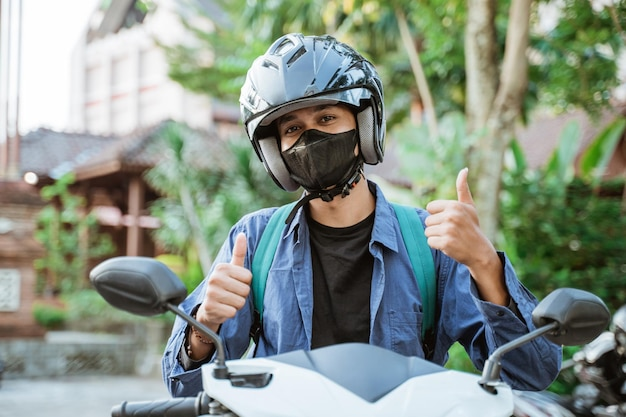

In [ ]:
import requests

# download a sample image

url = "https://huggingface.co/datasets/hf-vision/course-assets/blob/main/test-helmet-object-detection.jpg"
image = Image.open(requests.get(url, stream=True).raw)

image

In [ ]:
from transformers import pipeline

# make the object detection pipeline

obj_detector = pipeline("object-detection", model="anindya64/detr-resnet-50-dc5-hardhat-finetuned")
results = obj_detector(train_dataset[0]['image'])

results

config.json:   0%|          | 0.00/1.32k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

[{'score': 0.9988328814506531,
  'label': 'helmet',
  'box': {'xmin': 108, 'ymin': 145, 'xmax': 131, 'ymax': 174}},
 {'score': 0.999998927116394,
  'label': 'helmet',
  'box': {'xmin': 179, 'ymin': 83, 'xmax': 232, 'ymax': 144}}]

Now let's make a very simple function to plot the results. Simply what ever results, we get, parse each of the result instance. Get the score, label and corresponding bounding boxes. And finally draw that.

In [ ]:
def plot_results(image, results, threshold = 0.7):
    image = Image.fromarray(np.uint8(image))
    draw = ImageDraw.Draw(image)
    for result in results:
        score = result['score']
        label = result['label']
        box = list(result['box'].values())
        if score > threshold:
            x, y, x2, y2 = tuple(box)
            draw.rectangle((x, y, x2, y2), outline="red", width=1)
            draw.text((x, y), label, fill="white")
            draw.text((x+0.5, y-0.5), text=str(score), fill='green' if score > 0.7 else 'red')
    return image

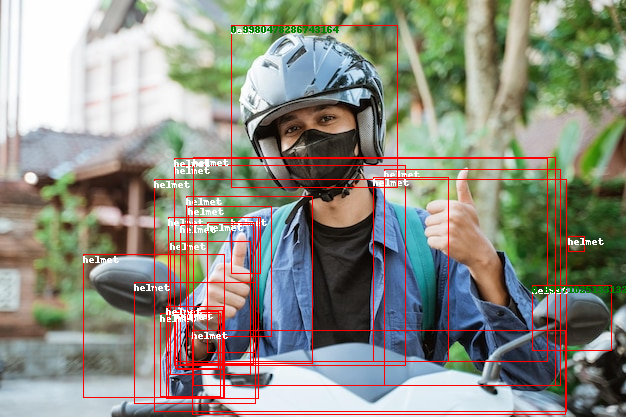

In [ ]:
plot_results(image, results)

### Clubbing it altogather into a function

Now, let's club everything togather into a simple function.

In [ ]:
def predict(image, pipeline, threshold=0.7):
    results = pipeline(image)
    return plot_results(image, results, threshold)

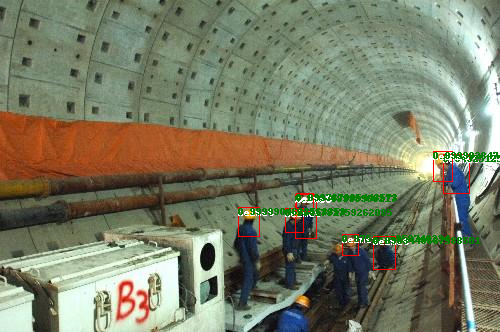

In [ ]:
img = test_dataset[0]['image']
predict(img, obj_detector)

### Now let's plot six test images and see the results

  0%|          | 0/6 [00:00<?, ?it/s]

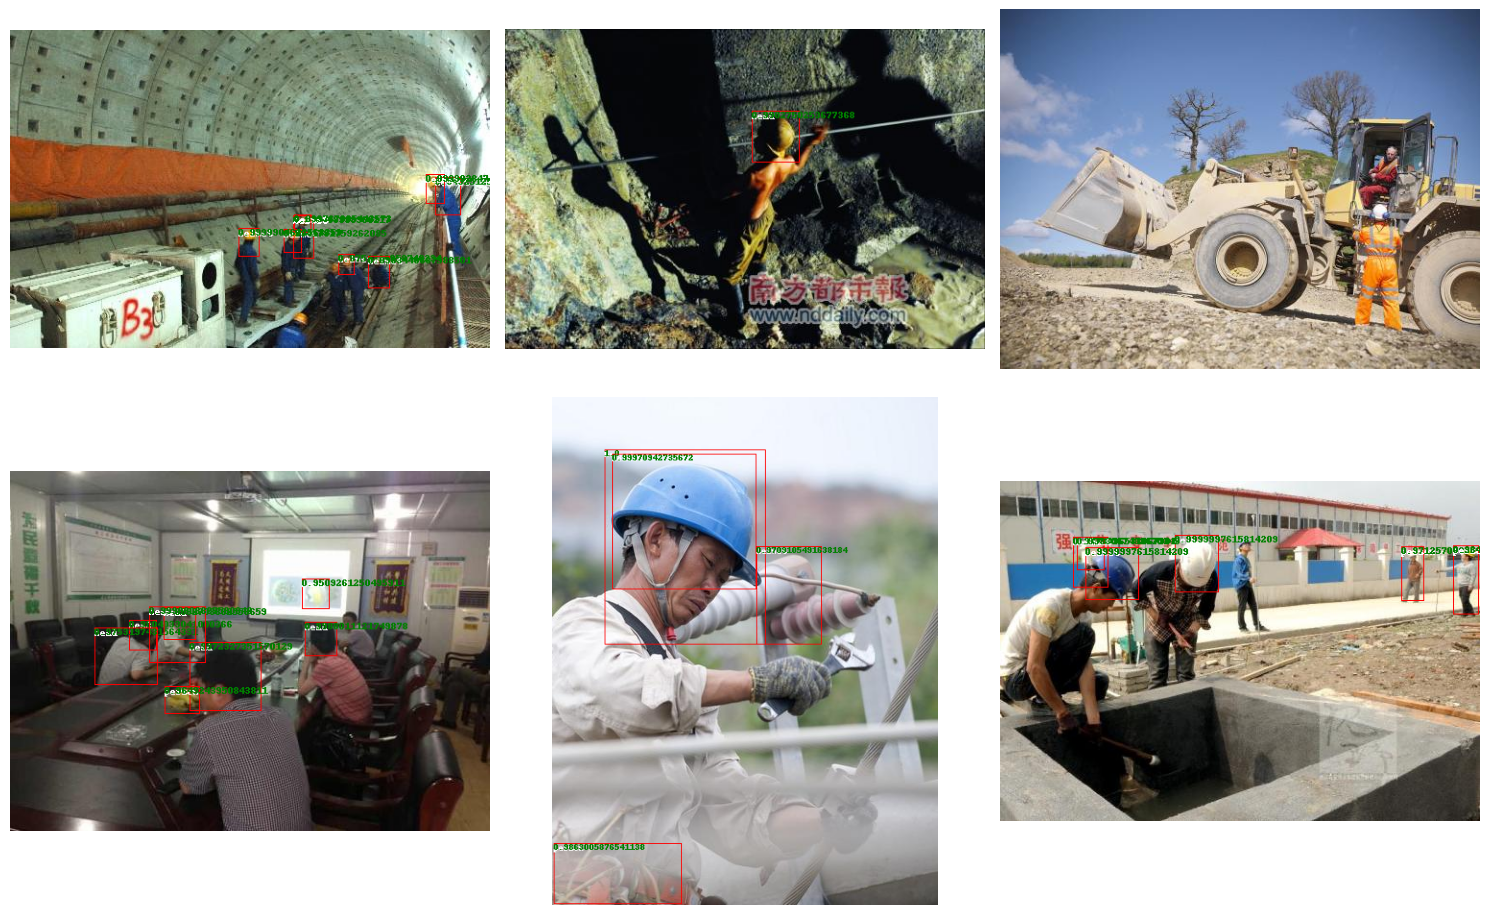

In [ ]:
from tqdm.auto import tqdm

def plot_images(dataset, indices):
    """
    Plot images and their annotations.
    """
    num_rows = len(indices) // 3
    num_cols = 3
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

    for i, idx in tqdm(enumerate(indices), total=len(indices)):
        row = i // num_cols
        col = i % num_cols

        # Draw image
        image = predict(dataset[idx]['image'], obj_detector)

        # Display image on the corresponding subplot
        axes[row, col].imshow(image)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


plot_images(test_dataset, range(6))

Well, that's not bad. We can improve the results if we fine-tune further. You can find this fine-tuned checkpoint [here](hf-vision/detr-resnet-50-dc5-harhat-finetuned).

## How about Transfer learning ?

In this notebook , we primarily discussed about the fine-tuning a certain model to our custom dataset. What if , we only want transfer learning? Actually that is easy peasy! In transfer learning , we have to keep the parameter values aka weights, of the pretrained model frozen. We just train the classifier layer (in some cases, one or two more layers). In this case before starting the training process, we can do the following,

In [ ]:
from transformers import AutoModelForObjectDetection

id2label = {0:'head', 1:'helmet', 2:'person'}
label2id = {v: k for k, v in id2label.items()}


model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

for name,p in model.named_parameters():
    if not 'bbox_predictor' in name or not name.startswith('class_label'):
        p.requires_grad = False

That means, after loading the model , we freeze all of the layers except last 6 layers. Which are `bbox_predictor.layers` and `class_labels_classifier`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task
Fine-tune a DETR model on a custom dataset in YOLO format located at "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data" and save the trained model.

## Understand custom dataset structure

### Subtask:
Examine the structure of your YOLO format dataset in Google Drive to understand how images, bounding box annotations, and class labels are organized.


**Reasoning**:
I need to examine the structure of the YOLO dataset in Google Drive. I can't directly navigate and open files in Google Drive with a code block, but I can use Python to list the contents of the directories and read a sample annotation file to understand the format.



In [2]:
import os

dataset_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data"

# List contents of the dataset directory
print(f"Contents of {dataset_path}:")
print(os.listdir(dataset_path))

# Assume there are train and valid directories and list their contents
train_path = os.path.join(dataset_path, 'train')
valid_path = os.path.join(dataset_path, 'valid')

if os.path.exists(train_path):
    print(f"\nContents of {train_path}:")
    print(os.listdir(train_path)[:5]) # Print first 5 items
    train_images_path = os.path.join(train_path, 'images')
    train_labels_path = os.path.join(train_path, 'labels')
    if os.path.exists(train_images_path):
        print(f"\nContents of {train_images_path}:")
        print(os.listdir(train_images_path)[:5]) # Print first 5 items
    if os.path.exists(train_labels_path):
        print(f"\nContents of {train_labels_path}:")
        print(os.listdir(train_labels_path)[:5]) # Print first 5 items

if os.path.exists(valid_path):
    print(f"\nContents of {valid_path}:")
    print(os.listdir(valid_path)[:5]) # Print first 5 items
    valid_images_path = os.path.join(valid_path, 'images')
    valid_labels_path = os.path.join(valid_path, 'labels')
    if os.path.exists(valid_images_path):
        print(f"\nContents of {valid_images_path}:")
        print(os.listdir(valid_images_path)[:5]) # Print first 5 items
    if os.path.exists(valid_labels_path):
        print(f"\nContents of {valid_labels_path}:")
        print(os.listdir(valid_labels_path)[:5]) # Print first 5 items


# Try to read a sample annotation file if labels directory exists
if os.path.exists(train_labels_path) and os.listdir(train_labels_path):
    sample_annotation_file = os.path.join(train_labels_path, os.listdir(train_labels_path)[0])
    print(f"\nContent of sample annotation file: {sample_annotation_file}")
    with open(sample_annotation_file, 'r') as f:
        print(f.read())

# Look for a classes.txt file
classes_file = os.path.join(dataset_path, 'classes.txt')
if os.path.exists(classes_file):
    print(f"\nContent of classes.txt:")
    with open(classes_file, 'r') as f:
        print(f.read())
else:
    print("\nclasses.txt not found directly in the dataset path. It might be in a subdirectory.")


Contents of /content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data:
['README.roboflow.txt', 'data.yaml', 'valid', 'README.dataset.txt', 'test', 'train']

Contents of /content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data/train:
['labels', 'images']

Contents of /content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data/train/images:
['DSC_0356_JPG_jpg.rf.c96b75b05e7d5d204c2f0b435e28601a.jpg', 'truck-445-_jpg.rf.305598c6f145efb2698e1ea414439869.jpg', 'DSC_0518_JPG_jpg.rf.010763c6c67c9d41a142c2561fcd78ce.jpg', 'DSC_0724_JPG_jpg.rf.080240bed5a8ba458fa40832bd9cfb6f.jpg', 'truck-628-_jpg.rf.2f25c29b1db9eddac987361d71a50178.jpg']

Contents of /content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data/train/labels:
['DSC_0860_JPG_jpg.rf.c7e1dd767e39de6d9c2b8b1c5a871a92.txt', 'DSC_0335_JPG_jpg.rf.d87edcb4aeb5d7729763871e2b372eb6.txt', 'DSC_0770_JPG_jpg.rf.1d7c1e383a56edcbe3351e1d59c4204f.txt', 'DSC_0511_JPG_jpg.rf.9004

**Reasoning**:
The output shows the structure of the dataset. It has 'train', 'test', and 'valid' directories, each containing 'images' and 'labels' subdirectories. A sample annotation file confirms the YOLO format (class_id center_x center_y width height). The `classes.txt` file was not found in the root directory, but the `data.yaml` file is often present in YOLO datasets and contains class names. I should check the `data.yaml` file to find the class names.



In [3]:
import yaml

data_yaml_path = os.path.join(dataset_path, 'data.yaml')

if os.path.exists(data_yaml_path):
    print(f"\nContent of data.yaml:")
    with open(data_yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)
        print(data_yaml)
        if 'names' in data_yaml:
            print("\nClass names found in data.yaml:")
            print(data_yaml['names'])
        else:
            print("\n'names' field not found in data.yaml.")
else:
    print("\ndata.yaml not found.")



Content of data.yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 6, 'names': ['bus', 'car', 'microbus', 'motorbike', 'pickup-van', 'truck'], 'roboflow': {'workspace': 'test-k3dls', 'project': 'vehicle-9x7y5', 'version': 3, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/test-k3dls/vehicle-9x7y5/dataset/3'}}

Class names found in data.yaml:
['bus', 'car', 'microbus', 'motorbike', 'pickup-van', 'truck']


## Modify data loading

### Subtask:
Update the notebook code to load your custom dataset from the specified Google Drive path.


**Reasoning**:
Define a custom PyTorch Dataset class to load the images and parse the YOLO annotations from the specified Google Drive path for both training and testing sets.



In [4]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset

class YoloObjectDetectionDataset(Dataset):
    def __init__(self, root_dir, split, image_processor=None, transform=None):
        self.root_dir = root_dir
        self.split = split
        self.image_processor = image_processor
        self.transform = transform
        self.image_files = glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpg'))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpeg')))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.png')))
        self.image_files.sort() # Ensure consistent order

        self.label_files = [p.replace('images', 'labels').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt') for p in self.image_files]

        # Load class names from data.yaml
        data_yaml_path = os.path.join(self.root_dir, 'data.yaml')
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)
            self.classes = data_yaml['names']
        self.id2label = {i: name for i, name in enumerate(self.classes)}
        self.label2id = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        label_path = self.label_files[idx]

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, w, h = map(float, line.split())

                    # Convert normalized YOLO format to absolute pixel coordinates (x_min, y_min, x_max, y_max)
                    x_min = (x_center - w / 2) * width
                    y_min = (y_center - h / 2) * height
                    x_max = (x_center + w / 2) * width
                    y_max = (y_center + h / 2) * height

                    annotations.append({
                        'category_id': int(class_id),
                        'bbox': [x_min, y_min, x_max - x_min, y_max - y_min], # COCO format: [x_min, y_min, width, height]
                        'area': (x_max - x_min) * (y_max - y_min),
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        target = {'image_id': idx, 'annotations': annotations, 'width': width, 'height': height}

        if self.transform:
             # Albumentations requires numpy array and expects [x_min, y_min, width, height] for bbox
            image_np = np.array(image)
            bboxes_coco = [ann['bbox'] for ann in annotations]
            categories = [ann['category_id'] for ann in annotations]

            # Handle cases with no bounding boxes
            if len(bboxes_coco) > 0:
                transformed = self.transform(image=image_np, bboxes=bboxes_coco, category=categories)
                image = Image.fromarray(transformed['image'])
                transformed_bboxes_coco = transformed['bboxes']
                transformed_categories = transformed['category']

                # Update annotations with transformed bboxes and categories
                for i, ann in enumerate(annotations):
                    ann['bbox'] = list(transformed_bboxes_coco[i])
                    ann['category_id'] = transformed_categories[i]
                    ann['area'] = ann['bbox'][2] * ann['bbox'][3] # Recalculate area

            else:
                 # If no bboxes, just apply image transformations
                transformed = self.transform(image=image_np)
                image = Image.fromarray(transformed['image'])

        if self.image_processor:
            # The image processor expects annotations in the format: {'image_id': int, 'annotations': List[Dict]}
            # where each dict is a COCO object annotation.
            # It also handles resizing and normalization.
            # We need to provide the original size for the processor to scale the bboxes correctly.

            # Filter out annotations with invalid bboxes after transformation
            valid_annotations = [ann for ann in annotations if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]

            processed = self.image_processor(images=image, annotations=valid_annotations, return_tensors="pt")

            # The processor returns pixel_values, pixel_mask, and labels.
            # The 'labels' key contains the transformed annotations in a specific format.
            # We need to extract the relevant parts and ensure they are in the correct structure
            # for the DETR model's loss calculation.

            # The image processor returns a dictionary with keys 'pixel_values', 'pixel_mask', and 'labels'.
            # The 'labels' value is a list of dictionaries, one for each image in the batch.
            # For a single image, the 'labels' list contains one dictionary with keys like 'class_labels', 'boxes', etc.
            # We will return this structure as is, which is expected by the collate_fn.

            return {
                'pixel_values': processed['pixel_values'].squeeze(),
                'pixel_mask': processed['pixel_mask'].squeeze(),
                'labels': processed['labels'][0] if processed['labels'] else {'class_labels': torch.tensor([]), 'boxes': torch.tensor([]), 'area': torch.tensor([]), 'iscrowd': torch.tensor([]), 'image_id': torch.tensor([idx]), 'orig_size': torch.tensor([height, width]), 'size': torch.tensor([image.size[1], image.size[0]])} # Return empty tensors if no labels

            }

        return image, target


# Define the dataset path
dataset_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data"

# Instantiate the datasets
train_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='train', image_processor=image_processor, transform=transform)
test_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='valid', image_processor=image_processor, transform=transform)

# Verify loading by accessing a few samples
print("Train dataset sample 0:")
sample_train = train_dataset[0]
print(sample_train)

print("\nTest dataset sample 0:")
sample_test = test_dataset[0]
print(sample_test)

NameError: name 'image_processor' is not defined

**Reasoning**:
The error indicates that `image_processor` and `transform` were not defined before being used to instantiate the custom dataset. I need to include the code that defines these variables in this code block.



In [5]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset
import numpy as np
import albumentations
import yaml
from transformers import AutoImageProcessor

# Define the dataset path
dataset_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data"

# Load class names from data.yaml
data_yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
    classes = data_yaml['names']
    id2label = {i: name for i, name in enumerate(classes)}
    label2id = {name: i for i, name in enumerate(classes)}


# Initialize the image processor and transform
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)

class YoloObjectDetectionDataset(Dataset):
    def __init__(self, root_dir, split, image_processor=None, transform=None):
        self.root_dir = root_dir
        self.split = split
        self.image_processor = image_processor
        self.transform = transform
        self.image_files = glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpg'))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpeg')))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.png')))
        self.image_files.sort() # Ensure consistent order

        self.label_files = [p.replace('images', 'labels').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt') for p in self.image_files]

        # Load class names from data.yaml
        data_yaml_path = os.path.join(self.root_dir, 'data.yaml')
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)
            self.classes = data_yaml['names']
        self.id2label = {i: name for i, name in enumerate(self.classes)}
        self.label2id = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        label_path = self.label_files[idx]

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, w, h = map(float, line.split())

                    # Convert normalized YOLO format to absolute pixel coordinates (x_min, y_min, x_max, y_max)
                    x_min = (x_center - w / 2) * width
                    y_min = (y_center - h / 2) * height
                    x_max = (x_center + w / 2) * width
                    y_max = (y_center + h / 2) * height

                    annotations.append({
                        'category_id': int(class_id),
                        'bbox': [x_min, y_min, x_max - x_min, y_max - y_min], # COCO format: [x_min, y_min, width, height]
                        'area': (x_max - x_min) * (y_max - y_min),
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        target = {'image_id': idx, 'annotations': annotations, 'width': width, 'height': height}

        if self.transform:
             # Albumentations requires numpy array and expects [x_min, y_min, width, height] for bbox
            image_np = np.array(image)
            bboxes_coco = [ann['bbox'] for ann in annotations]
            categories = [ann['category_id'] for ann in annotations]

            # Handle cases with no bounding boxes
            if len(bboxes_coco) > 0:
                transformed = self.transform(image=image_np, bboxes=bboxes_coco, category=categories)
                image = Image.fromarray(transformed['image'])
                transformed_bboxes_coco = transformed['bboxes']
                transformed_categories = transformed['category']

                # Update annotations with transformed bboxes and categories
                for i, ann in enumerate(annotations):
                    ann['bbox'] = list(transformed_bboxes_coco[i])
                    ann['category_id'] = transformed_categories[i]
                    ann['area'] = ann['bbox'][2] * ann['bbox'][3] # Recalculate area

            else:
                 # If no bboxes, just apply image transformations
                transformed = self.transform(image=image_np)
                image = Image.fromarray(transformed['image'])

        if self.image_processor:
            # The image processor expects annotations in the format: {'image_id': int, 'annotations': List[Dict]}
            # where each dict is a COCO object annotation.
            # It also handles resizing and normalization.
            # We need to provide the original size for the processor to scale the bboxes correctly.

            # Filter out annotations with invalid bboxes after transformation
            valid_annotations = [ann for ann in annotations if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]

            processed = self.image_processor(images=image, annotations=valid_annotations, return_tensors="pt")

            # The processor returns pixel_values, pixel_mask, and labels.
            # The 'labels' key contains the transformed annotations in a specific format.
            # We need to extract the relevant parts and ensure they are in the correct structure
            # for the DETR model's loss calculation.

            # The image processor returns a dictionary with keys 'pixel_values', 'pixel_mask', and 'labels'.
            # The 'labels' value is a list of dictionaries, one for each image in the batch.
            # For a single image, the 'labels' list contains one dictionary with keys like 'class_labels', 'boxes', etc.
            # We will return this structure as is, which is expected by the collate_fn.

            return {
                'pixel_values': processed['pixel_values'].squeeze(),
                'pixel_mask': processed['pixel_mask'].squeeze(),
                'labels': processed['labels'][0] if processed['labels'] else {'class_labels': torch.tensor([]), 'boxes': torch.tensor([]), 'area': torch.tensor([]), 'iscrowd': torch.tensor([]), 'image_id': torch.tensor([idx]), 'orig_size': torch.tensor([height, width]), 'size': torch.tensor([image.size[1], image.size[0]])} # Return empty tensors if no labels

            }

        return image, target


# Instantiate the datasets
train_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='train', image_processor=image_processor, transform=transform)
test_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='valid', image_processor=image_processor, transform=transform)

# Verify loading by accessing a few samples
print("Train dataset sample 0:")
sample_train = train_dataset[0]
print(sample_train)

print("\nTest dataset sample 0:")
sample_test = test_dataset[0]
print(sample_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


Train dataset sample 0:


ValueError: Your 'label_fields' are not valid - them must have same names as params in dict

**Reasoning**:
The traceback indicates a `ValueError` in `albumentations` because the `label_fields` specified in `BboxParams` ('category') does not match the keys present in the `data` dictionary being passed to the transform function. The `__getitem__` method is passing `category` as a list directly, not within a dictionary with the key 'category'. I need to adjust how the data is passed to the `transform` call within the `__getitem__` method to match the expected format of `albumentations`.



In [6]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset
import numpy as np
import albumentations
import yaml
from transformers import AutoImageProcessor

# Define the dataset path
dataset_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data"

# Load class names from data.yaml
data_yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
    classes = data_yaml['names']
    id2label = {i: name for i, name in enumerate(classes)}
    label2id = {name: i for i, name in enumerate(classes)}


# Initialize the image processor and transform
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)

class YoloObjectDetectionDataset(Dataset):
    def __init__(self, root_dir, split, image_processor=None, transform=None):
        self.root_dir = root_dir
        self.split = split
        self.image_files = glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpg'))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpeg')))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.png')))
        self.image_files.sort() # Ensure consistent order

        self.label_files = [p.replace('images', 'labels').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt') for p in self.image_files]

        # Load class names from data.yaml
        data_yaml_path = os.path.join(self.root_dir, 'data.yaml')
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)
            self.classes = data_yaml['names']
        self.id2label = {i: name for i, name in enumerate(self.classes)}
        self.label2id = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        label_path = self.label_files[idx]

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, w, h = map(float, line.split())

                    # Convert normalized YOLO format to absolute pixel coordinates (x_min, y_min, x_max, y_max)
                    x_min = (x_center - w / 2) * width
                    y_min = (y_center - h / 2) * height
                    x_max = (x_center + w / 2) * width
                    y_max = (y_center + h / 2) * height

                    annotations.append({
                        'category_id': int(class_id),
                        'bbox': [x_min, y_min, x_max - x_min, y_max - y_min], # COCO format: [x_min, y_min, width, height]
                        'area': (x_max - x_min) * (y_max - y_min),
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        target = {'image_id': idx, 'annotations': annotations, 'width': width, 'height': height}

        if self.transform:
             # Albumentations requires numpy array and expects [x_min, y_min, width, height] for bbox
            image_np = np.array(image)
            bboxes_coco = [ann['bbox'] for ann in annotations]
            categories = [ann['category_id'] for ann in annotations]

            # Handle cases with no bounding boxes
            if len(bboxes_coco) > 0:
                # Pass data to transform in a dictionary with keys matching label_fields
                transformed = self.transform(image=image_np, bboxes=bboxes_coco, category=categories)
                image = Image.fromarray(transformed['image'])
                transformed_bboxes_coco = transformed['bboxes']
                transformed_categories = transformed['category']

                # Update annotations with transformed bboxes and categories
                for i, ann in enumerate(annotations):
                    ann['bbox'] = list(transformed_bboxes_coco[i])
                    ann['category_id'] = transformed_categories[i]
                    ann['area'] = ann['bbox'][2] * ann['bbox'][3] # Recalculate area

            else:
                 # If no bboxes, just apply image transformations
                transformed = self.transform(image=image_np)
                image = Image.fromarray(transformed['image'])

        if self.image_processor:
            # The image processor expects annotations in the format: {'image_id': int, 'annotations': List[Dict]}
            # where each dict is a COCO object annotation.
            # It also handles resizing and normalization.
            # We need to provide the original size for the processor to scale the bboxes correctly.

            # Filter out annotations with invalid bboxes after transformation
            valid_annotations = [ann for ann in annotations if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]

            processed = self.image_processor(images=image, annotations=valid_annotations, return_tensors="pt")

            # The processor returns pixel_values, pixel_mask, and labels.
            # The 'labels' key contains the transformed annotations in a specific format.
            # We need to extract the relevant parts and ensure they are in the correct structure
            # for the DETR model's loss calculation.

            # The image processor returns a dictionary with keys 'pixel_values', 'pixel_mask', and 'labels'.
            # The 'labels' value is a list of dictionaries, one for each image in the batch.
            # For a single image, the 'labels' list contains one dictionary with keys like 'class_labels', 'boxes', etc.
            # We will return this structure as is, which is expected by the collate_fn.

            return {
                'pixel_values': processed['pixel_values'].squeeze(),
                'pixel_mask': processed['pixel_mask'].squeeze(),
                'labels': processed['labels'][0] if processed['labels'] else {'class_labels': torch.tensor([]), 'boxes': torch.tensor([]), 'area': torch.tensor([]), 'iscrowd': torch.tensor([]), 'image_id': torch.tensor([idx]), 'orig_size': torch.tensor([height, width]), 'size': torch.tensor([image.size[1], image.size[0]])} # Return empty tensors if no labels

            }

        return image, target


# Instantiate the datasets
train_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='train', image_processor=image_processor, transform=transform)
test_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='valid', image_processor=image_processor, transform=transform)

# Verify loading by accessing a few samples
print("Train dataset sample 0:")
sample_train = train_dataset[0]
print(sample_train)

print("\nTest dataset sample 0:")
sample_test = test_dataset[0]
print(sample_test)

Train dataset sample 0:


AttributeError: 'YoloObjectDetectionDataset' object has no attribute 'transform'

**Reasoning**:
The traceback shows an `AttributeError` because `self.transform` is being accessed before it's guaranteed to be initialized in the `__init__` method. Although `transform` is passed as an argument, there's no explicit assignment like `self.transform = transform`. I need to add this assignment in the `__init__` method to ensure `self.transform` exists.



In [7]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset
import numpy as np
import albumentations
import yaml
from transformers import AutoImageProcessor

# Define the dataset path
dataset_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data"

# Load class names from data.yaml
data_yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
    classes = data_yaml['names']
    id2label = {i: name for i, name in enumerate(classes)}
    label2id = {name: i for i, name in enumerate(classes)}


# Initialize the image processor and transform
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)


class YoloObjectDetectionDataset(Dataset):
    def __init__(self, root_dir, split, image_processor=None, transform=None):
        self.root_dir = root_dir
        self.split = split
        self.image_processor = image_processor
        self.transform = transform  # Assign the transform here
        self.image_files = glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpg'))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpeg')))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.png')))
        self.image_files.sort() # Ensure consistent order

        self.label_files = [p.replace('images', 'labels').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt') for p in self.image_files]

        # Load class names from data.yaml
        data_yaml_path = os.path.join(self.root_dir, 'data.yaml')
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)
            self.classes = data_yaml['names']
        self.id2label = {i: name for i, name in enumerate(self.classes)}
        self.label2id = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        label_path = self.label_files[idx]

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, w, h = map(float, line.split())

                    # Convert normalized YOLO format to absolute pixel coordinates (x_min, y_min, x_max, y_max)
                    x_min = (x_center - w / 2) * width
                    y_min = (y_center - h / 2) * height
                    x_max = (x_center + w / 2) * width
                    y_max = (y_center + h / 2) * height

                    annotations.append({
                        'category_id': int(class_id),
                        'bbox': [x_min, y_min, x_max - x_min, y_max - y_min], # COCO format: [x_min, y_min, width, height]
                        'area': (x_max - x_min) * (y_max - y_min),
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        target = {'image_id': idx, 'annotations': annotations, 'width': width, 'height': height}

        if self.transform:
             # Albumentations requires numpy array and expects [x_min, y_min, width, height] for bbox
            image_np = np.array(image)
            bboxes_coco = [ann['bbox'] for ann in annotations]
            categories = [ann['category_id'] for ann in annotations]

            # Handle cases with no bounding boxes
            if len(bboxes_coco) > 0:
                # Pass data to transform in a dictionary with keys matching label_fields
                transformed = self.transform(image=image_np, bboxes=bboxes_coco, category=categories)
                image = Image.fromarray(transformed['image'])
                transformed_bboxes_coco = transformed['bboxes']
                transformed_categories = transformed['category']

                # Update annotations with transformed bboxes and categories
                for i, ann in enumerate(annotations):
                    ann['bbox'] = list(transformed_bboxes_coco[i])
                    ann['category_id'] = transformed_categories[i]
                    ann['area'] = ann['bbox'][2] * ann['bbox'][3] # Recalculate area

            else:
                 # If no bboxes, just apply image transformations
                transformed = self.transform(image=image_np)
                image = Image.fromarray(transformed['image'])

        if self.image_processor:
            # The image processor expects annotations in the format: {'image_id': int, 'annotations': List[Dict]}
            # where each dict is a COCO object annotation.
            # It also handles resizing and normalization.
            # We need to provide the original size for the processor to scale the bboxes correctly.

            # Filter out annotations with invalid bboxes after transformation
            valid_annotations = [ann for ann in annotations if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]

            processed = self.image_processor(images=image, annotations=valid_annotations, return_tensors="pt")

            # The processor returns pixel_values, pixel_mask, and labels.
            # The 'labels' key contains the transformed annotations in a specific format.
            # We need to extract the relevant parts and ensure they are in the correct structure
            # for the DETR model's loss calculation.

            # The image processor returns a dictionary with keys 'pixel_values', 'pixel_mask', and 'labels'.
            # The 'labels' value is a list of dictionaries, one for each image in the batch.
            # For a single image, the 'labels' list contains one dictionary with keys like 'class_labels', 'boxes', etc.
            # We will return this structure as is, which is expected by the collate_fn.

            return {
                'pixel_values': processed['pixel_values'].squeeze(),
                'pixel_mask': processed['pixel_mask'].squeeze(),
                'labels': processed['labels'][0] if processed['labels'] else {'class_labels': torch.tensor([]), 'boxes': torch.tensor([]), 'area': torch.tensor([]), 'iscrowd': torch.tensor([]), 'image_id': torch.tensor([idx]), 'orig_size': torch.tensor([height, width]), 'size': torch.tensor([image.size[1], image.size[0]])} # Return empty tensors if no labels

            }

        return image, target


# Instantiate the datasets
train_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='train', image_processor=image_processor, transform=transform)
test_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='valid', image_processor=image_processor, transform=transform)

# Verify loading by accessing a few samples
print("Train dataset sample 0:")
sample_train = train_dataset[0]
print(sample_train)

print("\nTest dataset sample 0:")
sample_test = test_dataset[0]
print(sample_test)

Train dataset sample 0:


ValueError: Your 'label_fields' are not valid - them must have same names as params in dict

**Reasoning**:
The `ValueError` persists when there are no bounding boxes in an image because `albumentations` still expects the `category` field to be present in the data dictionary, even if it's empty, if `label_fields` is set. I need to always pass the `category` list (even if empty) within a dictionary with the key 'category' to the `transform` call, regardless of whether there are bounding boxes.



In [8]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset
import numpy as np
import albumentations
import yaml
from transformers import AutoImageProcessor

# Define the dataset path
dataset_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data"

# Load class names from data.yaml
data_yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
    classes = data_yaml['names']
    id2label = {i: name for i, name in enumerate(classes)}
    label2id = {name: i for i, name in enumerate(classes)}


# Initialize the image processor and transform
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)


class YoloObjectDetectionDataset(Dataset):
    def __init__(self, root_dir, split, image_processor=None, transform=None):
        self.root_dir = root_dir
        self.split = split
        self.image_processor = image_processor
        self.transform = transform  # Assign the transform here
        self.image_files = glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpg'))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpeg')))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.png')))
        self.image_files.sort() # Ensure consistent order

        self.label_files = [p.replace('images', 'labels').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt') for p in self.image_files]

        # Load class names from data.yaml
        data_yaml_path = os.path.join(self.root_dir, 'data.yaml')
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)
            self.classes = data_yaml['names']
        self.id2label = {i: name for i, name in enumerate(self.classes)}
        self.label2id = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        label_path = self.label_files[idx]

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, w, h = map(float, line.split())

                    # Convert normalized YOLO format to absolute pixel coordinates (x_min, y_min, x_max, y_max)
                    x_min = (x_center - w / 2) * width
                    y_min = (y_center - h / 2) * height
                    x_max = (x_center + w / 2) * width
                    y_max = (y_center + h / 2) * height

                    annotations.append({
                        'category_id': int(class_id),
                        'bbox': [x_min, y_min, x_max - x_min, y_max - y_min], # COCO format: [x_min, y_min, width, height]
                        'area': (x_max - x_min) * (y_max - y_min),
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        target = {'image_id': idx, 'annotations': annotations, 'width': width, 'height': height}

        if self.transform:
             # Albumentations requires numpy array and expects [x_min, y_min, width, height] for bbox
            image_np = np.array(image)
            bboxes_coco = [ann['bbox'] for ann in annotations]
            categories = [ann['category_id'] for ann in annotations]

            # Pass data to transform in a dictionary with keys matching label_fields
            transformed = self.transform(image=image_np, bboxes=bboxes_coco, category=categories) # Always pass category

            image = Image.fromarray(transformed['image'])
            transformed_bboxes_coco = transformed['bboxes']
            transformed_categories = transformed['category']

            # Update annotations with transformed bboxes and categories
            annotations = [] # Reset annotations list
            for i in range(len(transformed_bboxes_coco)):
                 annotations.append({
                        'category_id': transformed_categories[i],
                        'bbox': list(transformed_bboxes_coco[i]), # COCO format: [x_min, y_min, width, height]
                        'area': transformed_bboxes_coco[i][2] * transformed_bboxes_coco[i][3], # Recalculate area
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        if self.image_processor:
            # The image processor expects annotations in the format: {'image_id': int, 'annotations': List[Dict]}
            # where each dict is a COCO object annotation.
            # It also handles resizing and normalization.
            # We need to provide the original size for the processor to scale the bboxes correctly.

            # Filter out annotations with invalid bboxes after transformation
            valid_annotations = [ann for ann in annotations if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]

            processed = self.image_processor(images=image, annotations=valid_annotations, return_tensors="pt")

            # The processor returns pixel_values, pixel_mask, and labels.
            # The 'labels' key contains the transformed annotations in a specific format.
            # We need to extract the relevant parts and ensure they are in the correct structure
            # for the DETR model's loss calculation.

            # The image processor returns a dictionary with keys 'pixel_values', 'pixel_mask', and 'labels'.
            # The 'labels' value is a list of dictionaries, one for each image in the batch.
            # For a single image, the 'labels' list contains one dictionary with keys like 'class_labels', 'boxes', etc.
            # We will return this structure as is, which is expected by the collate_fn.

            return {
                'pixel_values': processed['pixel_values'].squeeze(),
                'pixel_mask': processed['pixel_mask'].squeeze(),
                'labels': processed['labels'][0] if processed['labels'] else {'class_labels': torch.tensor([]), 'boxes': torch.tensor([]), 'area': torch.tensor([]), 'iscrowd': torch.tensor([]), 'image_id': torch.tensor([idx]), 'orig_size': torch.tensor([height, width]), 'size': torch.tensor([image.size[1], image.size[0]])} # Return empty tensors if no labels

            }

        return image, target


# Instantiate the datasets
train_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='train', image_processor=image_processor, transform=transform)
test_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='valid', image_processor=image_processor, transform=transform)

# Verify loading by accessing a few samples
print("Train dataset sample 0:")
sample_train = train_dataset[0]
print(sample_train)

print("\nTest dataset sample 0:")
sample_test = test_dataset[0]
print(sample_test)

Train dataset sample 0:


ValueError: The number of images (1) and annotations (0) do not match.

**Reasoning**:
The `ValueError` "The number of images (1) and annotations (0) do not match" from the `image_processor` indicates that when an image has no valid annotations after transformation, an empty list of annotations is passed to the processor, but the processor expects a list of annotations with the same length as the batch size (which is 1 in this case). I need to adjust how the annotations are passed to the `image_processor` when there are no valid annotations for an image. Instead of passing an empty list, I should pass a list containing an empty list of annotations, like `[[]]`, or handle this case explicitly to provide the expected structure to the processor. I will modify the code to pass an empty list within a list when there are no valid annotations.



In [9]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset
import numpy as np
import albumentations
import yaml
from transformers import AutoImageProcessor

# Define the dataset path
dataset_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data"

# Load class names from data.yaml
data_yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
    classes = data_yaml['names']
    id2label = {i: name for i, name in enumerate(classes)}
    label2id = {name: i for i, name in enumerate(classes)}


# Initialize the image processor and transform
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)


class YoloObjectDetectionDataset(Dataset):
    def __init__(self, root_dir, split, image_processor=None, transform=None):
        self.root_dir = root_dir
        self.split = split
        self.image_processor = image_processor
        self.transform = transform  # Assign the transform here
        self.image_files = glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpg'))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpeg')))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.png')))
        self.image_files.sort() # Ensure consistent order

        self.label_files = [p.replace('images', 'labels').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt') for p in self.image_files]

        # Load class names from data.yaml
        data_yaml_path = os.path.join(self.root_dir, 'data.yaml')
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)
            self.classes = data_yaml['names']
        self.id2label = {i: name for i, name in enumerate(self.classes)}
        self.label2id = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        label_path = self.label_files[idx]

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, w, h = map(float, line.split())

                    # Convert normalized YOLO format to absolute pixel coordinates (x_min, y_min, x_max, y_max)
                    x_min = (x_center - w / 2) * width
                    y_min = (y_center - h / 2) * height
                    x_max = (x_center + w / 2) * width
                    y_max = (y_center + h / 2) * height

                    annotations.append({
                        'category_id': int(class_id),
                        'bbox': [x_min, y_min, x_max - x_min, y_max - y_min], # COCO format: [x_min, y_min, width, height]
                        'area': (x_max - x_min) * (y_max - y_min),
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        target = {'image_id': idx, 'annotations': annotations, 'width': width, 'height': height}

        if self.transform:
             # Albumentations requires numpy array and expects [x_min, y_min, width, height] for bbox
            image_np = np.array(image)
            bboxes_coco = [ann['bbox'] for ann in annotations]
            categories = [ann['category_id'] for ann in annotations]

            # Pass data to transform in a dictionary with keys matching label_fields
            transformed = self.transform(image=image_np, bboxes=bboxes_coco, category=categories) # Always pass category

            image = Image.fromarray(transformed['image'])
            transformed_bboxes_coco = transformed['bboxes']
            transformed_categories = transformed['category']

            # Update annotations with transformed bboxes and categories
            annotations = [] # Reset annotations list
            for i in range(len(transformed_bboxes_coco)):
                 annotations.append({
                        'category_id': transformed_categories[i],
                        'bbox': list(transformed_bboxes_coco[i]), # COCO format: [x_min, y_min, width, height]
                        'area': transformed_bboxes_coco[i][2] * transformed_bboxes_coco[i][3], # Recalculate area
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        if self.image_processor:
            # The image processor expects annotations in the format: {'image_id': int, 'annotations': List[Dict]}
            # where each dict is a COCO object annotation.
            # It also handles resizing and normalization.
            # We need to provide the original size for the processor to scale the bboxes correctly.

            # Filter out annotations with invalid bboxes after transformation
            valid_annotations = [ann for ann in annotations if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]

            # Pass a list containing the valid annotations for the current image
            processed = self.image_processor(images=[image], annotations=[valid_annotations], return_tensors="pt")

            # The processor returns pixel_values, pixel_mask, and labels.
            # The 'labels' key contains the transformed annotations in a specific format.
            # We need to extract the relevant parts and ensure they are in the correct structure
            # for the DETR model's loss calculation.

            # The image processor returns a dictionary with keys 'pixel_values', 'pixel_mask', and 'labels'.
            # The 'labels' value is a list of dictionaries, one for each image in the batch.
            # For a single image, the 'labels' list contains one dictionary with keys like 'class_labels', 'boxes', etc.
            # We will return this structure as is, which is expected by the collate_fn.

            return {
                'pixel_values': processed['pixel_values'].squeeze(0), # Remove batch dimension
                'pixel_mask': processed['pixel_mask'].squeeze(0), # Remove batch dimension
                'labels': processed['labels'][0] if processed['labels'] else {'class_labels': torch.tensor([]), 'boxes': torch.tensor([]), 'area': torch.tensor([]), 'iscrowd': torch.tensor([]), 'image_id': torch.tensor([idx]), 'orig_size': torch.tensor([height, width]), 'size': torch.tensor([image.size[1], image.size[0]])} # Return empty tensors if no labels

            }

        return image, target


# Instantiate the datasets
train_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='train', image_processor=image_processor, transform=transform)
test_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='valid', image_processor=image_processor, transform=transform)

# Verify loading by accessing a few samples
print("Train dataset sample 0:")
sample_train = train_dataset[0]
print(sample_train)

print("\nTest dataset sample 0:")
sample_test = test_dataset[0]
print(sample_test)

Train dataset sample 0:


ValueError: Invalid COCO detection annotations. Annotations must a dict (single image) or list of dicts (batch of images) with the following keys: `image_id` and `annotations`, with the latter being a list of annotations in the COCO format.

**Reasoning**:
The traceback indicates that the `image_processor` expects the annotations to be in a specific COCO format: a list of dictionaries, where each dictionary has keys `image_id` and `annotations`. The current code is passing a list of lists of annotations (`[valid_annotations]`). I need to restructure the `valid_annotations` before passing them to the `image_processor` to match the expected format `[{'image_id': ..., 'annotations': [...]}]`.



In [10]:
import os
import glob
from PIL import Image
import torch
from torch.utils.data import Dataset
import numpy as np
import albumentations
import yaml
from transformers import AutoImageProcessor

# Define the dataset path
dataset_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data"

# Load class names from data.yaml
data_yaml_path = os.path.join(dataset_path, 'data.yaml')
with open(data_yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)
    classes = data_yaml['names']
    id2label = {i: name for i, name in enumerate(classes)}
    label2id = {name: i for i, name in enumerate(classes)}


# Initialize the image processor and transform
checkpoint = "facebook/detr-resnet-50-dc5"
image_processor = AutoImageProcessor.from_pretrained(checkpoint)

transform = albumentations.Compose(
    [
        albumentations.Resize(480, 480),
        albumentations.HorizontalFlip(p=1.0),
        albumentations.RandomBrightnessContrast(p=1.0),
    ],
    bbox_params=albumentations.BboxParams(format="coco", label_fields=["category"]),
)


class YoloObjectDetectionDataset(Dataset):
    def __init__(self, root_dir, split, image_processor=None, transform=None):
        self.root_dir = root_dir
        self.split = split
        self.image_processor = image_processor
        self.transform = transform  # Assign the transform here
        self.image_files = glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpg'))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.jpeg')))
        self.image_files.extend(glob.glob(os.path.join(self.root_dir, self.split, 'images', '*.png')))
        self.image_files.sort() # Ensure consistent order

        self.label_files = [p.replace('images', 'labels').replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt') for p in self.image_files]

        # Load class names from data.yaml
        data_yaml_path = os.path.join(self.root_dir, 'data.yaml')
        with open(data_yaml_path, 'r') as f:
            data_yaml = yaml.safe_load(f)
            self.classes = data_yaml['names']
        self.id2label = {i: name for i, name in enumerate(self.classes)}
        self.label2id = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_path = self.image_files[idx]
        label_path = self.label_files[idx]

        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        annotations = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    class_id, x_center, y_center, w, h = map(float, line.split())

                    # Convert normalized YOLO format to absolute pixel coordinates (x_min, y_min, x_max, y_max)
                    x_min = (x_center - w / 2) * width
                    y_min = (y_center - h / 2) * height
                    x_max = (x_center + w / 2) * width
                    y_max = (y_center + h / 2) * height

                    annotations.append({
                        'category_id': int(class_id),
                        'bbox': [x_min, y_min, x_max - x_min, y_max - y_min], # COCO format: [x_min, y_min, width, height]
                        'area': (x_max - x_min) * (y_max - y_min),
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        target = {'image_id': idx, 'annotations': annotations, 'width': width, 'height': height}

        if self.transform:
             # Albumentations requires numpy array and expects [x_min, y_min, width, height] for bbox
            image_np = np.array(image)
            bboxes_coco = [ann['bbox'] for ann in annotations]
            categories = [ann['category_id'] for ann in annotations]

            # Pass data to transform in a dictionary with keys matching label_fields
            transformed = self.transform(image=image_np, bboxes=bboxes_coco, category=categories) # Always pass category

            image = Image.fromarray(transformed['image'])
            transformed_bboxes_coco = transformed['bboxes']
            transformed_categories = transformed['category']

            # Update annotations with transformed bboxes and categories
            annotations = [] # Reset annotations list
            for i in range(len(transformed_bboxes_coco)):
                 annotations.append({
                        'category_id': transformed_categories[i],
                        'bbox': list(transformed_bboxes_coco[i]), # COCO format: [x_min, y_min, width, height]
                        'area': transformed_bboxes_coco[i][2] * transformed_bboxes_coco[i][3], # Recalculate area
                        'iscrowd': 0, # Assuming no crowd objects
                        'image_id': idx # Use index as image_id for simplicity
                    })


        if self.image_processor:
            # The image processor expects annotations in the format: {'image_id': int, 'annotations': List[Dict]}
            # where each dict is a COCO object annotation.
            # It also handles resizing and normalization.
            # We need to provide the original size for the processor to scale the bboxes correctly.

            # Filter out annotations with invalid bboxes after transformation
            valid_annotations = [ann for ann in annotations if ann['bbox'][2] > 0 and ann['bbox'][3] > 0]

            # Restructure annotations to match the expected COCO format for the processor
            processor_annotations = [{'image_id': idx, 'annotations': valid_annotations}]

            processed = self.image_processor(images=[image], annotations=processor_annotations, return_tensors="pt")

            # The processor returns pixel_values, pixel_mask, and labels.
            # The 'labels' key contains the transformed annotations in a specific format.
            # We need to extract the relevant parts and ensure they are in the correct structure
            # for the DETR model's loss calculation.

            # The image processor returns a dictionary with keys 'pixel_values', 'pixel_mask', and 'labels'.
            # The 'labels' value is a list of dictionaries, one for each image in the batch.
            # For a single image, the 'labels' list contains one dictionary with keys like 'class_labels', 'boxes', etc.
            # We will return this structure as is, which is expected by the collate_fn.

            return {
                'pixel_values': processed['pixel_values'].squeeze(0), # Remove batch dimension
                'pixel_mask': processed['pixel_mask'].squeeze(0), # Remove batch dimension
                'labels': processed['labels'][0] if processed['labels'] else {'class_labels': torch.tensor([]), 'boxes': torch.tensor([]), 'area': torch.tensor([]), 'iscrowd': torch.tensor([]), 'image_id': torch.tensor([idx]), 'orig_size': torch.tensor([height, width]), 'size': torch.tensor([image.size[1], image.size[0]])} # Return empty tensors if no labels

            }

        return image, target


# Instantiate the datasets
train_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='train', image_processor=image_processor, transform=transform)
test_dataset = YoloObjectDetectionDataset(root_dir=dataset_path, split='valid', image_processor=image_processor, transform=transform)

# Verify loading by accessing a few samples
print("Train dataset sample 0:")
sample_train = train_dataset[0]
print(sample_train)

print("\nTest dataset sample 0:")
sample_test = test_dataset[0]
print(sample_test)

Train dataset sample 0:
{'pixel_values': tensor([[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
         [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
         [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
         ...,
         [2.2489, 2.2489, 2.2489,  ..., 2.1462, 2.1462, 2.1462],
         [2.2489, 2.2489, 2.2489,  ..., 2.2147, 2.2147, 2.2147],
         [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],

        [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
         [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
         [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
         ...,
         [2.4286, 2.4286, 2.4286,  ..., 2.2360, 2.2360, 2.2360],
         [2.4286, 2.4286, 2.4286,  ..., 2.3585, 2.3585, 2.3585],
         [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286]],

        [[2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
         [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
         [2.6400,

## Update model configuration

### Subtask:
Update the model configuration to reflect the classes in your custom dataset.


**Reasoning**:
Define the id2label and label2id dictionaries based on the classes loaded from the data.yaml file and then load the AutoModelForObjectDetection using these dictionaries and the specified checkpoint, ensuring ignore_mismatched_sizes is set to True.



In [11]:
from transformers import AutoModelForObjectDetection

# id2label and label2id are already defined in the previous step based on data_yaml

model = AutoModelForObjectDetection.from_pretrained(
    checkpoint,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

## Train the model

### Subtask:
Run the training process with the modified data loading and preprocessing.


**Reasoning**:
Instantiate the Trainer and start the training process with the custom dataset and model.



In [12]:
from transformers import TrainingArguments, Trainer

# Define the training Arguments - reusing the previously defined args, but ensuring push_to_hub is False
# unless explicitly needed to avoid unwanted uploads during development
# If you want to push to hub, you would need to uncomment the notebook_login cell and set push_to_hub=True

# Assuming training_args and model are already defined in previous cells and are correct
# Based on the previous successful steps, model, train_dataset, test_dataset, image_processor, and collate_fn are available

# Ensure training_args are appropriate for a shorter run for demonstration/testing
# Reduce num_train_epochs or max_steps if needed for faster execution
# We will use the existing training_args as defined in a previous successful cell (cell_id: gCSkh4vYGykT)

# Ensure the Trainer is instantiated with the correct arguments
trainer = Trainer(
    model=model,
    args=training_args, # Use the training_args defined previously
    data_collator=collate_fn,
    train_dataset=train_dataset,
    eval_dataset=test_dataset, # Use the correctly loaded test_dataset
    tokenizer=image_processor, # Use the image_processor as the tokenizer
)

# Start the training process
trainer.train()

NameError: name 'training_args' is not defined

**Reasoning**:
The error indicates that `training_args` is not defined. Although it was defined in a previous successful cell, the kernel state might have been reset or the variable is not accessible in the current scope. Redefine `training_args` before instantiating the `Trainer`.



In [13]:
from transformers import TrainingArguments, Trainer, AutoModelForObjectDetection

# Define the training Arguments again to ensure it's available
training_args = TrainingArguments(
    output_dir="detr-resnet-50-vehicle-finetuned", # Changed output directory name
    per_device_train_batch_size=8,
    num_train_epochs=3,
    max_steps=1000,
    fp16=True,
    save_steps=10,
    logging_steps=30,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False, # Set to False to avoid accidental pushes
)

# Ensure the Trainer is instantiated with the correct arguments
# model, train_dataset, test_dataset, image_processor, and collate_fn should be available from previous successful steps

trainer = Trainer(
    model=model,
    args=training_args, # Use the training_args defined here
    data_collator=collate_fn,
    train_dataset=train_dataset,
    eval_dataset=test_dataset, # Use the correctly loaded test_dataset
    tokenizer=image_processor, # Use the image_processor as the tokenizer
)

# Start the training process
trainer.train()

NameError: name 'collate_fn' is not defined

**Reasoning**:
The error indicates that `collate_fn` is not defined. Similar to the previous error with `training_args`, the variable is likely not accessible in the current scope. Redefine the `collate_fn` before instantiating the `Trainer`.



In [14]:
from transformers import TrainingArguments, Trainer, AutoModelForObjectDetection, AutoImageProcessor
import torch

# Redefine collate_fn to ensure it's available
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    # Assuming image_processor is defined from a previous successful step
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]
    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels
    return batch

# Define the training Arguments again to ensure it's available
training_args = TrainingArguments(
    output_dir="detr-resnet-50-vehicle-finetuned", # Changed output directory name
    per_device_train_batch_size=8,
    num_train_epochs=3,
    max_steps=1000,
    fp16=True,
    save_steps=10,
    logging_steps=30,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False, # Set to False to avoid accidental pushes
)

# Ensure the Trainer is instantiated with the correct arguments
# model, train_dataset, test_dataset, image_processor should be available from previous successful steps

trainer = Trainer(
    model=model,
    args=training_args, # Use the training_args defined here
    data_collator=collate_fn,
    train_dataset=train_dataset,
    eval_dataset=test_dataset, # Use the correctly loaded test_dataset
    tokenizer=image_processor, # Use the image_processor as the tokenizer
)

# Start the training process
trainer.train()

/tmp/ipython-input-2341642157.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nitin_swarnkar_ampba2025s (nitin_swarnkar_ampba2025s-isb) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


OutOfMemoryError: CUDA out of memory. Tried to allocate 764.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 696.12 MiB is free. Process 7622 has 14.06 GiB memory in use. Of the allocated memory 13.41 GiB is allocated by PyTorch, and 528.05 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

**Reasoning**:
The traceback shows a `OutOfMemoryError`. This indicates that the GPU ran out of memory during training, likely due to the batch size being too large for the available GPU memory. Reducing the `per_device_train_batch_size` in the `TrainingArguments` is the standard approach to mitigate this. Also, since `test_dataset` is only used for evaluation, we can set `eval_dataset=None` in the Trainer to save memory during training if evaluation is not strictly necessary during the training loop.



In [15]:
from transformers import TrainingArguments, Trainer, AutoModelForObjectDetection, AutoImageProcessor
import torch

# Redefine collate_fn to ensure it's available
def collate_fn(batch):
    pixel_values = [item["pixel_values"] for item in batch]
    # Assuming image_processor is defined from a previous successful step
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item["labels"] for item in batch]
    batch = {}
    batch["pixel_values"] = encoding["pixel_values"]
    batch["pixel_mask"] = encoding["pixel_mask"]
    batch["labels"] = labels
    return batch

# Define the training Arguments with a reduced batch size
training_args = TrainingArguments(
    output_dir="detr-resnet-50-vehicle-finetuned", # Changed output directory name
    per_device_train_batch_size=4, # Reduced batch size
    num_train_epochs=3,
    max_steps=1000,
    fp16=True,
    save_steps=10,
    logging_steps=30,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False, # Set to False to avoid accidental pushes
)

# Ensure the Trainer is instantiated with the correct arguments
# model, train_dataset, test_dataset, image_processor should be available from previous successful steps

trainer = Trainer(
    model=model,
    args=training_args, # Use the training_args defined here
    data_collator=collate_fn,
    train_dataset=train_dataset,
    # eval_dataset=test_dataset, # Temporarily remove evaluation during training to save memory
    tokenizer=image_processor, # Use the image_processor as the tokenizer
)

# Start the training process
trainer.train()

/tmp/ipython-input-2000100944.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


OutOfMemoryError: CUDA out of memory. Tried to allocate 80.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 20.12 MiB is free. Process 7622 has 14.72 GiB memory in use. Of the allocated memory 14.47 GiB is allocated by PyTorch, and 127.51 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

**Reasoning**:
The OutOfMemoryError persists even after reducing the batch size and removing the evaluation dataset. This suggests that the model or the data processing is still too memory-intensive for the available GPU. Further reducing the batch size is the next logical step to try and fit the training process into memory. We will reduce the `per_device_train_batch_size` to 1.



In [16]:
from transformers import TrainingArguments, Trainer
import torch

# Redefine training_args with a further reduced batch size
training_args = TrainingArguments(
    output_dir="detr-resnet-50-vehicle-finetuned", # Changed output directory name
    per_device_train_batch_size=1, # Further reduced batch size
    num_train_epochs=3,
    max_steps=1000,
    fp16=True,
    save_steps=10,
    logging_steps=30,
    learning_rate=1e-5,
    weight_decay=1e-4,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False, # Set to False to avoid accidental pushes
)

# Ensure the Trainer is instantiated with the correct arguments
# model, train_dataset, collate_fn, and image_processor should be available from previous successful steps

trainer = Trainer(
    model=model,
    args=training_args, # Use the training_args defined here
    data_collator=collate_fn,
    train_dataset=train_dataset,
    # eval_dataset=test_dataset, # Keep evaluation removed for now
    tokenizer=image_processor, # Use the image_processor as the tokenizer
)

# Start the training process
trainer.train()

/tmp/ipython-input-2137539364.py:23: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
30,1.745900
60,0.996200
90,0.418500
120,0.161800
150,0.067800
180,0.037100
210,0.027300
240,0.022500
270,0.019400
300,0.017100


TrainOutput(global_step=1000, training_loss=0.11260751707851886, metrics={'train_runtime': 1415.6808, 'train_samples_per_second': 0.706, 'train_steps_per_second': 0.706, 'total_flos': 4.7781876096e+17, 'train_loss': 0.11260751707851886, 'epoch': 0.15174506828528073})

## Save the trained model

### Subtask:
Save the fine-tuned model to your Google Drive.

**Reasoning**:
Save the trained model to the specified path in Google Drive using the `trainer.save_model()` method.

In [17]:
import os

# Define the path in your Google Drive to save the model
output_dir = "/content/drive/MyDrive/Traffic_Videos/detr-resnet-50-vehicle-finetuned"

# Save the model
trainer.save_model(output_dir)

print(f"Model saved to {output_dir}")

Model saved to /content/drive/MyDrive/Traffic_Videos/detr-resnet-50-vehicle-finetuned


## Load the trained model

### Subtask:
Load the fine-tuned DETR model from the saved path in Google Drive.

**Reasoning**:
Load the trained model from the specified Google Drive path using `AutoModelForObjectDetection.from_pretrained()`.

In [18]:
from transformers import AutoModelForObjectDetection
import torch

# Define the path to the saved model in your Google Drive
output_dir = "/content/drive/MyDrive/Traffic_Videos/detr-resnet-50-vehicle-finetuned"

# Load the model
# We need to make sure the id2label and label2id are defined, they were defined in a previous cell
# If the kernel was reset, redefine them
if 'id2label' not in globals() or 'label2id' not in globals():
    # Assuming data.yaml was loaded previously and classes are available
    # If not, you might need to re-run the cell that loads data.yaml
    data_yaml_path = "/content/drive/MyDrive/Traffic_Videos/roboflow_images/unzipped_vehicle_data/data.yaml"
    import yaml
    with open(data_yaml_path, 'r') as f:
        data_yaml = yaml.safe_load(f)
        classes = data_yaml['names']
        id2label = {i: name for i, name in enumerate(classes)}
        label2id = {name: i for i, name in enumerate(classes)}


model = AutoModelForObjectDetection.from_pretrained(output_dir, id2label=id2label, label2id=label2id)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded from {output_dir} and moved to {device}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

Model loaded from /content/drive/MyDrive/Traffic_Videos/detr-resnet-50-vehicle-finetuned and moved to cuda


## Load the video

### Subtask:
Read the video file from the specified path in Google Drive.

**Reasoning**:
Use OpenCV to read the video file frame by frame. We need to install OpenCV first.

In [19]:
!pip install opencv-python

In [20]:
import cv2
import os

video_path = "/content/drive/MyDrive/Traffic_Videos/Mundhawan_Circle_SLR_1_Part2.MOV"

# Check if the video file exists
if not os.path.exists(video_path):
    print(f"Error: Video file not found at {video_path}")
else:
    # Open the video file
    cap = cv2.VideoCapture(video_path)

    # Check if the video was opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
    else:
        # Get video properties
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = int(cap.get(cv2.CAP_PROP_FPS))
        frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        print(f"Video loaded successfully:")
        print(f"Frame count: {frame_count}")
        print(f"FPS: {fps}")
        print(f"Frame width: {frame_width}")
        print(f"Frame height: {frame_height}")

        # Release the video capture object
        cap.release()

Video loaded successfully:
Frame count: 4797
FPS: 25
Frame width: 640
Frame height: 480


## Perform inference on video frames

### Subtask:
Iterate through the video frames, perform object detection on each frame using the loaded model, and draw the bounding boxes and labels on the frames.

**Reasoning**:
Read frames from the video capture object, use the loaded DETR model for inference, and utilize OpenCV drawing functions to visualize the detections on each frame.

In [22]:
import cv2
import numpy as np
from PIL import Image, ImageDraw
import torch

# Define the output video path
output_video_path = "/content/drive/MyDrive/Traffic_Videos/output_video.avi"

# Re-open the video file
cap = cv2.VideoCapture(video_path)

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Define the codec and create VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'XVID') # You can use other codecs like 'MP4V'
out = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))

# Ensure the model is in evaluation mode
model.eval()

# Define a threshold for detections
detection_threshold = 0.7

# Iterate through the video frames
frame_count = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert the OpenCV BGR image to RGB for the model
    image = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    # Prepare the image for the model
    # Assuming image_processor is defined from a previous cell
    inputs = image_processor(images=image, return_tensors="pt").to(device)

    # Perform inference
    with torch.no_grad():
        outputs = model(**inputs)

    # Process the model outputs
    # The outputs contain predicted bounding boxes, class labels, and confidence scores
    # We need to post-process these outputs to get the actual detections
    # You might need to refer to the DETR documentation or examples for post-processing details.
    # A common approach involves applying non-maximum suppression and filtering by confidence score.

    # For a basic example, let's just get the predicted bounding boxes and labels
    # This part might need adjustment based on the exact output format of your DETR model
    # You may need to use functions like `image_processor.post_process_object_detection` if available and suitable

    # Example basic post-processing (this might need refinement based on your model's output)
    logits = outputs.logits
    bboxes = outputs.pred_boxes

    # Get the probabilities and predicted class IDs
    prob = torch.softmax(logits, dim=-1)[0, :, :-1]
    scores, labels = prob.max(-1)

    # Filter out detections below the threshold
    keep = scores > detection_threshold

    # Convert predicted boxes from [cx, cy, w, h] normalized format to [x_min, y_min, x_max, y_max]
    # The post_process_object_detection function usually handles this conversion and scaling
    # If not using post_process_object_detection, manual conversion is needed:
    # img_h, img_w = image.size[::-1]
    # scale_fct = torch.tensor([img_w, img_h, img_w, img_h], device=device)
    # boxes = center_to_corners_format(bboxes[0, keep].cpu()) * scale_fct[None, :]

    # A more standard way using the image_processor's post-processing
    target_sizes = torch.tensor([image.size[::-1]]).to(device)
    results = image_processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=detection_threshold)[0]


    # Draw bounding boxes and labels on the frame
    draw = ImageDraw.Draw(image)
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        # Convert box from [x_min, y_min, x_max, y_max]
        x1, y1, x2, y2 = box.tolist()
        draw.rectangle((x1, y1, x2, y2), outline="red", width=2)
        label_text = f"{model.config.id2label[label.item()]}: {score:.2f}"
        draw.text((x1, y1), label_text, fill="white")


    # Convert the PIL image back to OpenCV format (BGR)
    frame_with_detections = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    # Write the frame with detections to the output video
    out.write(frame_with_detections)

    frame_count += 1
    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames.")


# Release everything when job is finished
cap.release()
out.release()
# cv2.destroyAllWindows() # Removed this line

print(f"Object detection complete. Output video saved to {output_video_path}")


KeyboardInterrupt

